<a href="https://colab.research.google.com/github/jfavian2011/Data-Science-Cohort-20/blob/main/SQL_1_Chinook_project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project SQL - Chinook


## Chinook data set

See the lecture on SQLite3 using the Chinook data set to set up the software, database, and tables, as well as for the links to ancillary information about the data set.


In [ ]:
# Install the sqlite package for Ubuntu
# Download the Chinook sqlite database

## Come up with questions about your data
Have a look at the Entity-Relation ( ER ) diagram to help come up with questions.

* What sort of information is in this dataset?
* How many records are there?
* How many different countries (states, counties, cities, etc) have records in this data set?


If you are stuck, here are some ideas for questions:
- https://github.com/LucasMcL/15-sql_queries_02-chinook/blob/master/README.md
- [Using the R language]( https://rpubs.com/enext777/636199 )
- [Search Google]( https://www.google.com/search?q=chinook+database+questions )



## Use SQL queries to pull specific information

Do NOT pull all the data and then filter using DataFrame methods etc. Make sure and use AT LEAST 13 of the 15 SQL options listed below. (You may have to get creative and come up with more questions to ask/answer.)


### Basic Queries


In [ ]:
%%capture
import sqlite3 as db
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# helpe to keep clutter out
def run(sql):
    with db.connect('chinook.db') as conn:
        return pd.read_sql_query(sql, conn)

In [ ]:
%%capture
%%bash
apt-get update
apt-get install -y sqlite3
wget https://github.com/lerocha/chinook-database/raw/master/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite -O chinook.db
pip install ipython-sql

#### SELECT (with * and with column names)


In [ ]:
# what are the first 5 tracks
query = """
SELECT
    Name,
    Composer,
    UnitPrice
FROM Track
LIMIT 5
"""
run(query)

,Name,Composer,UnitPrice
0,For Those About To Rock (We Salute You),"Angus Young, Malcolm Young, Brian Johnson",0.99
1,Balls to the Wall,"U. Dirkschneider, W. Hoffmann, H. Frank, P. Ba...",0.99
2,Fast As a Shark,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",0.99
3,Restless and Wild,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D...",0.99
4,Princess of the Dawn,Deaffy & R.A. Smith-Diesel,0.99


#### WHERE


In [ ]:
# how many records sold to the city of Brussels
query = """
SELECT * FROM Invoice
WHERE BillingCity = 'Brussels'
"""
run(query)

,InvoiceId,CustomerId,InvoiceDate,BillingAddress,BillingCity,BillingState,BillingCountry,BillingPostalCode,Total
0,3,8,2021-01-03 00:00:00,Grétrystraat 63,Brussels,None,Belgium,1000,5.94
1,55,8,2021-08-24 00:00:00,Grétrystraat 63,Brussels,None,Belgium,1000,0.99
2,176,8,2023-02-15 00:00:00,Grétrystraat 63,Brussels,None,Belgium,1000,1.98
3,187,8,2023-03-28 00:00:00,Grétrystraat 63,Brussels,None,Belgium,1000,13.86
4,242,8,2023-11-26 00:00:00,Grétrystraat 63,Brussels,None,Belgium,1000,8.91
5,371,8,2025-07-02 00:00:00,Grétrystraat 63,Brussels,None,Belgium,1000,1.98
6,394,8,2025-10-04 00:00:00,Grétrystraat 63,Brussels,None,Belgium,1000,3.96


#### AND


In [ ]:
# invoices with total between 1.98 and 3.96 using the AND operator.
query = """
SELECT * FROM Invoice
WHERE Total >= 1.98
  AND Total <= 3.96
"""
run(query)

,InvoiceId,CustomerId,InvoiceDate,BillingAddress,BillingCity,BillingState,BillingCountry,BillingPostalCode,Total
0,1,2,2021-01-01 00:00:00,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,1.98
1,2,4,2021-01-02 00:00:00,Ullevålsveien 14,Oslo,None,Norway,0171,3.96
2,7,38,2021-02-01 00:00:00,Barbarossastraße 19,Berlin,None,Germany,10779,1.98
3,8,40,2021-02-01 00:00:00,"8, Rue Hanovre",Paris,None,France,75002,1.98
4,9,42,2021-02-02 00:00:00,"9, Place Louis Barthou",Bordeaux,None,France,33000,3.96
...,...,...,...,...,...,...,...,...,...
168,401,46,2025-11-04 00:00:00,3 Chatham Street,Dublin,Dublin,Ireland,None,3.96
169,406,21,2025-12-04 00:00:00,801 W 4th Street,Reno,NV,USA,89503,1.98
170,407,23,2025-12-04 00:00:00,69 Salem Street,Boston,MA,USA,2113,1.98
171,408,25,2025-12-05 00:00:00,319 N. Frances Street,Madison,WI,USA,53703,3.96


#### OR


In [ ]:
# customers located in either Brazil or Canada
query = """
SELECT FirstName, LastName, Country
FROM Customer
WHERE Country = 'Brazil'
   OR Country = 'Canada'
"""
run(query)

,FirstName,LastName,Country
0,Luís,Gonçalves,Brazil
1,François,Tremblay,Canada
2,Eduardo,Martins,Brazil
3,Alexandre,Rocha,Brazil
4,Roberto,Almeida,Brazil
5,Fernanda,Ramos,Brazil
6,Mark,Philips,Canada
7,Jennifer,Peterson,Canada
8,Robert,Brown,Canada
9,Edward,Francis,Canada


#### LIKE (with % or _ wildcard)


In [ ]:
# songs with heart in title
query = """
SELECT TrackId, Name
FROM Track
WHERE Name LIKE '%Heart%'
LIMIT 10
"""
run(query)

,TrackId,Name
0,144,Heart Of Gold
1,456,Heart of the Night
2,841,Bringin' On The Heartbreak
3,1578,Heartbreaker
4,1631,Heartbreaker
5,1749,Heart Of Lothian: Wide Boy / Curtain Call
6,1972,Kickstart My Heart
7,1996,Heart-Shaped Box
8,2119,Heart In Your Hand
9,2273,Sheer Heart Attack


#### BETWEEN


In [ ]:
# how many invoices between 1.98 and 5 dollars
query = """
SELECT * FROM Invoice
WHERE Total BETWEEN 1.98 AND 5.00
"""
run(query)

,InvoiceId,CustomerId,InvoiceDate,BillingAddress,BillingCity,BillingState,BillingCountry,BillingPostalCode,Total
0,1,2,2021-01-01 00:00:00,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,1.98
1,2,4,2021-01-02 00:00:00,Ullevålsveien 14,Oslo,None,Norway,0171,3.96
2,7,38,2021-02-01 00:00:00,Barbarossastraße 19,Berlin,None,Germany,10779,1.98
3,8,40,2021-02-01 00:00:00,"8, Rue Hanovre",Paris,None,France,75002,1.98
4,9,42,2021-02-02 00:00:00,"9, Place Louis Barthou",Bordeaux,None,France,33000,3.96
...,...,...,...,...,...,...,...,...,...
173,401,46,2025-11-04 00:00:00,3 Chatham Street,Dublin,Dublin,Ireland,None,3.96
174,406,21,2025-12-04 00:00:00,801 W 4th Street,Reno,NV,USA,89503,1.98
175,407,23,2025-12-04 00:00:00,69 Salem Street,Boston,MA,USA,2113,1.98
176,408,25,2025-12-05 00:00:00,319 N. Frances Street,Madison,WI,USA,53703,3.96


#### LIMIT



In [ ]:
# show the 5 most recent invoices
query = """
SELECT * FROM Invoice
ORDER BY InvoiceDate DESC
LIMIT 5
"""
run(query)

,InvoiceId,CustomerId,InvoiceDate,BillingAddress,BillingCity,BillingState,BillingCountry,BillingPostalCode,Total
0,412,58,2025-12-22 00:00:00,"12,Community Centre",Delhi,None,India,110017,1.99
1,411,44,2025-12-14 00:00:00,Porthaninkatu 9,Helsinki,None,Finland,00530,13.86
2,410,35,2025-12-09 00:00:00,"Rua dos Campeões Europeus de Viena, 4350",Porto,None,Portugal,None,8.91
3,409,29,2025-12-06 00:00:00,796 Dundas Street West,Toronto,ON,Canada,M6J 1V1,5.94
4,408,25,2025-12-05 00:00:00,319 N. Frances Street,Madison,WI,USA,53703,3.96


### Sorting and Grouping


#### ORDER BY


In [ ]:
# order by last name
query = """
SELECT FirstName, LastName, City
FROM Customer
ORDER BY LastName ASC
LIMIT 10
"""
run(query)

,FirstName,LastName,City
0,Roberto,Almeida,Rio de Janeiro
1,Julia,Barnett,Salt Lake City
2,Camille,Bernard,Paris
3,Michelle,Brooks,New York
4,Robert,Brown,Toronto
5,Kathy,Chase,Reno
6,Richard,Cunningham,Fort Worth
7,Marc,Dubois,Lyon
8,João,Fernandes,Lisbon
9,Edward,Francis,Ottawa


#### DISTINCT


In [ ]:
# clean list of every country shipped to with no duplicates
query = """
SELECT DISTINCT BillingCountry
FROM Invoice
ORDER BY BillingCountry ASC
"""
run(query)

,BillingCountry
0,Argentina
1,Australia
2,Austria
3,Belgium
4,Brazil
5,Canada
6,Chile
7,Czech Republic
8,Denmark
9,Finland


#### GROUP BY



In [ ]:
# tallying up how many orders came from each country
query = """
SELECT BillingCountry, COUNT(InvoiceId) AS OrderCount
FROM Invoice
GROUP BY BillingCountry
"""
run(query)

,BillingCountry,OrderCount
0,Argentina,7
1,Australia,7
2,Austria,7
3,Belgium,7
4,Brazil,35
5,Canada,56
6,Chile,7
7,Czech Republic,14
8,Denmark,7
9,Finland,7


### Aggregates


#### MAX


In [ ]:
# most expensive invoice total
query = """
SELECT MAX(Total) AS Top_Price
FROM Invoice
"""
run(query)

,Top_Price
0,25.86


#### MIN


In [ ]:
# lowest price any customer has paid on an invoice
query = """
SELECT MIN(Total) AS Low_Price
FROM Invoice
"""
run(query)

,Low_Price
0,0.99


#### SUM


In [ ]:
# sum up every invoice to get the total store revenue
query = """
SELECT SUM(Total) AS Total_Revenue
FROM Invoice
"""
run(query)

,Total_Revenue
0,2328.6


#### AVG


In [ ]:
# calculating the average of all invoice totals
query = """
SELECT AVG(Total) AS Average_Sale
FROM Invoice
"""
run(query)

,Average_Sale
0,5.651942


#### COUNT



In [ ]:
# count how many rows exist for invoices that total exactly $1.98
query = """
SELECT COUNT(*) AS Two_Track_Sales
FROM Invoice
WHERE Total = 1.98
"""
run(query)

,Two_Track_Sales
0,111


Joins

In [ ]:
# combine customer names with their invoice totals
query = """
SELECT
    c.FirstName,
    c.LastName,
    i.InvoiceId,
    i.Total
FROM Customer AS c
JOIN Invoice AS i ON c.CustomerId = i.CustomerId
LIMIT 15
"""
run(query)

,FirstName,LastName,InvoiceId,Total
0,Leonie,Köhler,1,1.98
1,Bjørn,Hansen,2,3.96
2,Daan,Peeters,3,5.94
3,Mark,Philips,4,8.91
4,John,Gordon,5,13.86
5,Fynn,Zimmermann,6,0.99
6,Niklas,Schröder,7,1.98
7,Dominique,Lefebvre,8,1.98
8,Wyatt,Girard,9,3.96
9,Hugh,O'Reilly,10,5.94


## Make some plots

Make some cool plots to go with your data. Write SQL queries to get ONLY the information you need for each plot. (Don't pull ALL the data and then just plot a few columns.)



Plot 1: Top 10 countries by revenue

/tmp/ipykernel_21182/1106174121.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_country, x='Sales', y='BillingCountry', palette='viridis')


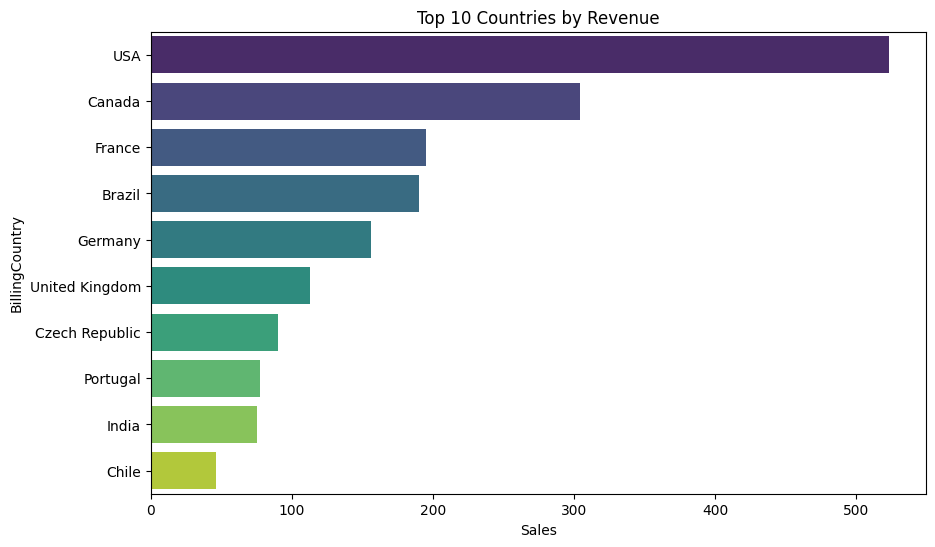

In [ ]:
# bar graph for total sales by country
df_country = run("""
SELECT BillingCountry, SUM(Total) as Sales
FROM Invoice
GROUP BY BillingCountry
ORDER BY Sales DESC
LIMIT 10
""")

plt.figure(figsize=(10, 6))
sns.barplot(data=df_country, x='Sales', y='BillingCountry', palette='viridis')
plt.title('Top 10 Countries by Revenue')
plt.show()

Plot 2: Popular Genres

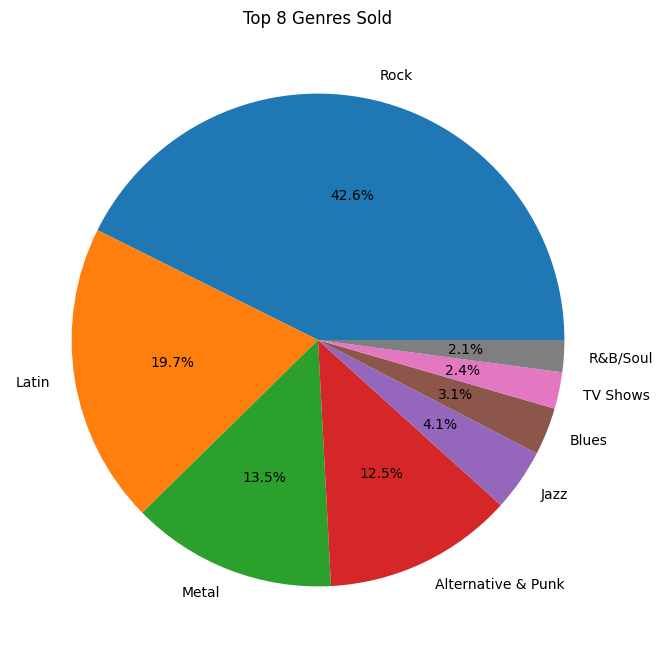

In [ ]:
# pie chart for the top selling music genres
df_genre = run("""
SELECT g.Name as Genre, COUNT(il.InvoiceLineId) as TracksSold
FROM Genre g
JOIN Track t ON g.GenreId = t.GenreId
JOIN InvoiceLine il ON t.TrackId = il.TrackId
GROUP BY g.Name
ORDER BY TracksSold DESC
LIMIT 8
""")

plt.figure(figsize=(8, 8))
plt.pie(df_genre['TracksSold'], labels=df_genre['Genre'], autopct='%1.1f%%')
plt.title('Top 8 Genres Sold')
plt.show()

plot 3: Sale price distribution

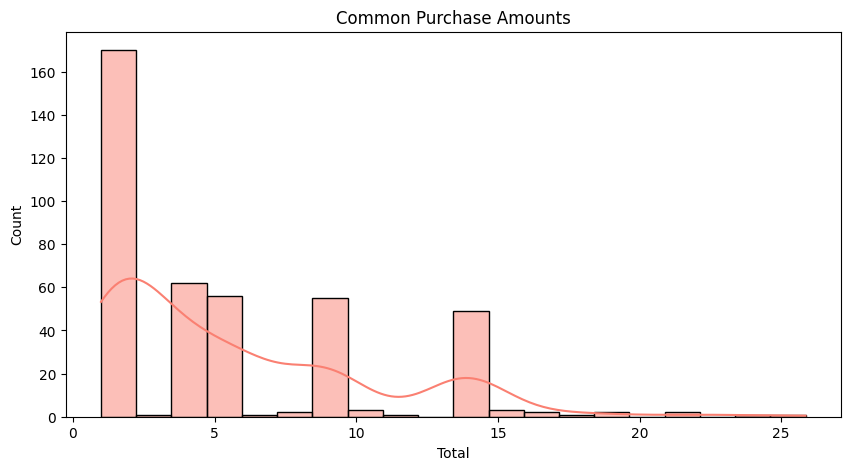

In [ ]:
# histogram of most common invoice amounts
df_dist = run("SELECT Total FROM Invoice")

plt.figure(figsize=(10, 5))
sns.histplot(df_dist['Total'], bins=20, kde=True, color='salmon')
plt.title('Common Purchase Amounts')
plt.show()

## EXTRA CREDIT:
* Use a CTE
* Use a query that joins two or more tables.
* Make a model to see if you can predict something
* Come up with something else cool to do with your data


## Project Conclusion: SQL Chinook
##Database Management:
I learned how to download a relational database to use as a primary data source.

## Filtering:
Instead of pulling a giant, messy file into Python and trying to clean it there, I used WHERE, AND, OR, and BETWEEN to grab only the exact rows I needed. Which makes the code much faster and more efficient.

##Questions:
I demonstrated how to use SQL to solve real-world business questions.

Sales volume for specific cities (Brussels)?

Finding specific price points ($1.98) to understand customer buying habits. Of two records at .99 cents each?

Searching for specific keywords within data using the LIKE command

##JOINs:
Ability to connect separate tables. By joining the Customer table with the Invoice table, I turned ID numbers into actual names, making the data readable and useful.

##Summarizing,
I used functions like SUM, AVG, MAX, and MIN to condense rows of data into single, meaningful numbers that describe the state of the business.

##Data Visualization:
I learned that SQL and Python work best as a team. I used SQL to "pre-shape" the data so that my Seaborn bar charts and histograms were clean and easy to interpret immedately.

##Bottom Line
My biggest takeaway is that SQL is the filter for the data. It allows me to take a massive database and narrow it down —the specific information needed to make a decision—before I even start the analysis.
